# Árboles de Decisión: Comparación de Profundidades

En este notebook trabajaremos con **árboles de decisión** para resolver un problema de clasificación.

Un árbol de decisión es un modelo de *aprendizaje supervisado* que toma decisiones dividiendo el espacio de datos en regiones cada vez más pequeñas, usando preguntas del tipo:

> ¿La característica X es mayor o menor que un cierto valor?

En cada nodo interno del árbol se hace una pregunta (una condición) sobre una característica, y en las hojas se encuentran las clases predichas.

**Objetivo del ejercicio**

1. Cargar un dataset provisto por el profesor.
2. Entrenar **tres árboles de decisión** con diferentes profundidades máximas.
3. Comparar el desempeño de los modelos para analizar:
   - Subajuste (underfitting)
   - Sobreajuste (overfitting)
   - Elección de una profundidad “adecuada” para el problema.


## 2️⃣ Carga y exploración del dataset

En esta sección debes:

1. Cargar el dataset mmnist_train desde un archivo (por ejemplo, CSV).
2. Mostrar las primeras filas del dataset para ver cómo están organizados los datos.
3. Indicar:
   - Cuántas filas tiene el dataset.
   - Cuántas columnas tiene el dataset.
4. Revisar si existen valores nulos o faltantes en alguna columna.
5. Escribir un breve comentario describiendo:
   - Qué representa cada fila.
   - Qué tipo de información contienen las columnas (en términos generales).


In [4]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv(r'C:\Users\Zyrmu\Downloads\platzi\Inteligencia Artificial\IA\IA_Mario_Morales\asignacion_3\mnist_train.csv')

# Display first rows
print("Primeras filas del dataset:")
print(df.head())

# Dataset information
print(f"\nDimensiones del dataset:")
print(f"  - Filas: {df.shape[0]}")
print(f"  - Columnas: {df.shape[1]}")

# Check for null values
print(f"\nValores nulos por columna:")
print(df.isnull().sum())

# Dataset description
print("\nDescripción del dataset:")
print(f"  - Cada fila representa una imagen de un dígito manuscrito (28x28 píxeles = 784 valores).")
print(f"  - Las primeras 784 columnas contienen los valores de intensidad de cada píxel (0-255).")
print(f"  - La última columna (label) contiene la etiqueta del dígito (0-9).")
print(f"\nEstadísticas básicas:")
print(df.describe())

Primeras filas del dataset:
   label  data_0  data_1  data_2  data_3  data_4  data_5  data_6  data_7  \
0      5       0       0       0       0       0       0       0       0   
1      0       0       0       0       0       0       0       0       0   
2      4       0       0       0       0       0       0       0       0   
3      1       0       0       0       0       0       0       0       0   
4      9       0       0       0       0       0       0       0       0   

   data_8  ...  data_774  data_775  data_776  data_777  data_778  data_779  \
0       0  ...         0         0         0         0         0         0   
1       0  ...         0         0         0         0         0         0   
2       0  ...         0         0         0         0         0         0   
3       0  ...         0         0         0         0         0         0   
4       0  ...         0         0         0         0         0         0   

   data_780  data_781  data_782  data_783  
0 

## 3️⃣ Preparación de las variables (X y y)

En esta sección debes:

1. Identificar que **X** son las imágenes (flattened: 784 pixeles).  
2. Identificar que **y** son las etiquetas (dígitos 0–9).  
3. Mostrar cuántas clases distintas hay en y.  
4. Escribir un comentario corto describiendo:
   - ¿Qué significa cada fila en X?
   - ¿Qué representa y?



In [5]:
# Preparación de X e y (Sección 3)
# Usamos el dataframe `df` ya definido en el notebook.

# 1-2. Definir X (imágenes) e y (etiquetas)
X = df.drop(columns='label')
y = df['label']

# 3. Mostrar cuántas clases distintas hay en y y cuáles son
n_classes = y.nunique()
classes = sorted(y.unique().tolist())

print(f"Forma de X: {X.shape}   # (n_ejemplos, n_atributos = 784)")
print(f"Forma de y: {y.shape}")
print(f"Número de clases distintas en y: {n_classes}")
print(f"Clases encontradas: {classes}")

# Mostrar distribución de clases para ver balanceo
print("\nDistribución de ejemplos por clase (y):")
print(y.value_counts().sort_index())

# 4. Comentario corto sobre X e y
print("\nComentarios:")
print(" - Cada fila en X representa una imagen en escala de grises aplanada de 28x28 píxeles (784 valores).")
print(" - Cada columna data_i es la intensidad del píxel i (valores típicamente entre 0 y 255).")
print(" - y contiene la etiqueta del dígito manuscrito (enteros 0-9) correspondiente a cada imagen.")

Forma de X: (55000, 784)   # (n_ejemplos, n_atributos = 784)
Forma de y: (55000,)
Número de clases distintas en y: 10
Clases encontradas: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

Distribución de ejemplos por clase (y):
label
0    5434
1    6212
2    5465
3    5622
4    5343
5    4963
6    5436
7    5702
8    5357
9    5466
Name: count, dtype: int64

Comentarios:
 - Cada fila en X representa una imagen en escala de grises aplanada de 28x28 píxeles (784 valores).
 - Cada columna data_i es la intensidad del píxel i (valores típicamente entre 0 y 255).
 - y contiene la etiqueta del dígito manuscrito (enteros 0-9) correspondiente a cada imagen.


## 4️⃣ División en entrenamiento y prueba

En esta sección debes:

1. Dividir los datos en:
   - 80% entrenamiento  
   - 20% prueba  
2. Usar `random_state` fijo para reproducibilidad.
3. Estratificar usando y, para mantener las proporciones de cada dígito.
4. Mostrar:
   - Cantidad de ejemplos en entrenamiento.
   - Cantidad de ejemplos en prueba.


In [6]:
from sklearn.model_selection import train_test_split

# 4️⃣ División en entrenamiento y prueba (80% train / 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Mostrar tamaños
n_train = X_train.shape[0]
n_test = X_test.shape[0]
total = n_train + n_test

print(f"Ejemplos totales: {total}")
print(f"  - Entrenamiento: {n_train} ({n_train/total*100:.1f}%)")
print(f"  - Prueba:        {n_test} ({n_test/total*100:.1f}%)\n")

# Comprobar estratificación: distribución por clase en train y test
print("Distribución de clases en y_train:")
print(y_train.value_counts().sort_index())
print("\nDistribución de clases en y_test:")
print(y_test.value_counts().sort_index())

Ejemplos totales: 55000
  - Entrenamiento: 44000 (80.0%)
  - Prueba:        11000 (20.0%)

Distribución de clases en y_train:
label
0    4347
1    4969
2    4372
3    4498
4    4274
5    3970
6    4349
7    4562
8    4286
9    4373
Name: count, dtype: int64

Distribución de clases en y_test:
label
0    1087
1    1243
2    1093
3    1124
4    1069
5     993
6    1087
7    1140
8    1071
9    1093
Name: count, dtype: int64


## 5️⃣ Definir las profundidades a evaluar

En esta sección debes:

1. Elegir **tres profundidades** para evaluar.  
   Recomendación para MNIST:  
   - 5  
   - 10  
   - 20  
*(Puedes ajustar)*

2. Justificar brevemente por qué comparar varias profundidades es importante en un problema con muchos atributos como MNIST.



In [7]:
# Sección 5: Definir profundidades a evaluar
# No se vuelven a importar ni redefinir X, y, etc. (ya están en el notebook).

# 1) Tres profundidades recomendadas para MNIST
depths = [5, 10, 20]

print("Profundidades seleccionadas:", depths)

# 2) Justificación breve (impresa para registro)
justification = (
    "Comparar varias profundidades permite observar el trade-off entre sesgo y varianza:\n"
    "- Profundidad baja (p.ej. 5): modelo más simple, riesgo de subajuste (underfitting).\n"
    "- Profundidad intermedia (p.ej. 10): busca un balance entre precisión y generalización.\n"
    "- Profundidad alta (p.ej. 20): mayor capacidad para ajustar detalles, pero mayor riesgo de sobreajuste\n"
    "  y mayor costo computacional en un problema de alta dimensionalidad como MNIST (784 features)."
)

print("\nJustificación:")
print(justification)

Profundidades seleccionadas: [5, 10, 20]

Justificación:
Comparar varias profundidades permite observar el trade-off entre sesgo y varianza:
- Profundidad baja (p.ej. 5): modelo más simple, riesgo de subajuste (underfitting).
- Profundidad intermedia (p.ej. 10): busca un balance entre precisión y generalización.
- Profundidad alta (p.ej. 20): mayor capacidad para ajustar detalles, pero mayor riesgo de sobreajuste
  y mayor costo computacional en un problema de alta dimensionalidad como MNIST (784 features).


## 6️⃣ Entrenamiento de los modelos (tres profundidades)

En esta sección debes entrenar **tres modelos de árbol de decisión**, uno por cada profundidad definida.

Para cada profundidad debes:

1. Crear un modelo con `max_depth` correspondiente.  
2. Entrenarlo usando X_train y y_train.  
3. Hacer predicciones con:
   - X_train  
   - X_test  
4. Calcular el **accuracy** en:
   - entrenamiento  
   - prueba  
5. Guardar los resultados (profundidad, accuracy train, accuracy test) para compararlos después.



In [8]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Diccionario para almacenar los modelos y resultados
models = {}
results = []

# Entrenar un árbol de decisión para cada profundidad
for depth in depths:
    print(f"\n{'='*60}")
    print(f"Entrenando árbol con max_depth = {depth}")
    print(f"{'='*60}")
    
    # 1. Crear el modelo con la profundidad especificada
    tree = DecisionTreeClassifier(max_depth=depth, random_state=42)
    
    # 2. Entrenar el modelo con los datos de entrenamiento
    tree.fit(X_train, y_train)
    
    # 3. Hacer predicciones en entrenamiento y prueba
    y_train_pred = tree.predict(X_train)
    y_test_pred = tree.predict(X_test)
    
    # 4. Calcular accuracy en entrenamiento y prueba
    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    
    # 5. Guardar el modelo y los resultados
    models[depth] = tree
    results.append({
        'Profundidad': depth,
        'Accuracy Entrenamiento': train_accuracy,
        'Accuracy Prueba': test_accuracy
    })
    
    # Mostrar resultados para cada profundidad
    print(f"Accuracy en ENTRENAMIENTO: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
    print(f"Accuracy en PRUEBA:        {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
    print(f"Diferencia (train - test): {train_accuracy - test_accuracy:.4f}")

print(f"\n{'='*60}")
print("Modelos entrenados exitosamente")
print(f"{'='*60}")


Entrenando árbol con max_depth = 5
Accuracy en ENTRENAMIENTO: 0.6549 (65.49%)
Accuracy en PRUEBA:        0.6566 (65.66%)
Diferencia (train - test): -0.0017

Entrenando árbol con max_depth = 10
Accuracy en ENTRENAMIENTO: 0.9055 (90.55%)
Accuracy en PRUEBA:        0.8528 (85.28%)
Diferencia (train - test): 0.0527

Entrenando árbol con max_depth = 20
Accuracy en ENTRENAMIENTO: 0.9958 (99.58%)
Accuracy en PRUEBA:        0.8647 (86.47%)
Diferencia (train - test): 0.1311

Modelos entrenados exitosamente


## 7️⃣ Tabla de comparación

En esta sección debes:

1. Crear una tabla que contenga:
   - Profundidad  
   - Accuracy entrenamiento  
   - Accuracy prueba  

2. Identificar visualmente cuál profundidad tuvo mejor desempeño.

3. Responder brevemente:
   - ¿Cuál profundidad tiene mayor accuracy en prueba?
   - ¿Alguna profundidad muestra diferencias grandes entre train y test?
   - ¿Qué podría significar esto?


In [9]:
# Tabla de comparación (Sección 7)
# Usa las variables ya definidas en el notebook: `results`

results_df = pd.DataFrame(results)
# Añadir diferencia train - test
results_df['Diferencia'] = results_df['Accuracy Entrenamiento'] - results_df['Accuracy Prueba']

# Mostrar la tabla
print("Tabla comparativa (raw accuracies):")
print(results_df.to_string(index=False))

# Identificar la mejor profundidad en prueba
best_idx = results_df['Accuracy Prueba'].idxmax()
best_row = results_df.loc[best_idx]
print(f"\nMejor en PRUEBA: Profundidad = {int(best_row['Profundidad'])} "
    f"con Accuracy Prueba = {best_row['Accuracy Prueba']:.4f}")

# Detectar diferencias grandes entre train y test (umbral = 0.05)
umbral = 0.05
big_gaps = results_df[results_df['Diferencia'] > umbral]

if not big_gaps.empty:
    print("\nProfundidades con diferencias grandes (posible sobreajuste):")
    for _, r in big_gaps.iterrows():
      print(f" - Profundidad {int(r['Profundidad'])}: "
          f"Train={r['Accuracy Entrenamiento']:.4f}, Test={r['Accuracy Prueba']:.4f}, "
          f"Diferencia={r['Diferencia']:.4f}")
else:
    print("\nNo se encontraron diferencias grandes entre train y test (umbral 0.05).")

# Breves conclusiones (respuestas a las preguntas de la sección)
print("\nRespuestas cortas:")
print(f" - ¿Cuál profundidad tiene mayor accuracy en prueba? -> {int(best_row['Profundidad'])}")
if not big_gaps.empty:
    print(" - ¿Alguna profundidad muestra diferencias grandes entre train y test? -> Sí (ver arriba).")
    print("   ¿Qué podría significar esto? -> Indica sobreajuste: el modelo ajusta muy bien el entrenamiento "
        "pero no generaliza igual en la prueba.")
else:
    print(" - ¿Alguna profundidad muestra diferencias grandes entre train y test? -> No.")
    print("   ¿Qué podría significar esto? -> No hay indicios fuertes de sobreajuste por la profundidad evaluada.")

Tabla comparativa (raw accuracies):
 Profundidad  Accuracy Entrenamiento  Accuracy Prueba  Diferencia
           5                0.654932         0.656636   -0.001705
          10                0.905477         0.852818    0.052659
          20                0.995795         0.864727    0.131068

Mejor en PRUEBA: Profundidad = 20 con Accuracy Prueba = 0.8647

Profundidades con diferencias grandes (posible sobreajuste):
 - Profundidad 10: Train=0.9055, Test=0.8528, Diferencia=0.0527
 - Profundidad 20: Train=0.9958, Test=0.8647, Diferencia=0.1311

Respuestas cortas:
 - ¿Cuál profundidad tiene mayor accuracy en prueba? -> 20
 - ¿Alguna profundidad muestra diferencias grandes entre train y test? -> Sí (ver arriba).
   ¿Qué podría significar esto? -> Indica sobreajuste: el modelo ajusta muy bien el entrenamiento pero no generaliza igual en la prueba.


## 8️⃣ Gráfica de desempeño

En esta sección debes:

1. Graficar las profundidades en el eje X.  
2. Graficar dos líneas:
   - Accuracy en entrenamiento  
   - Accuracy en prueba  

3. Interpretar la gráfica respondiendo:
   - ¿Aumentar profundidad siempre mejora el modelo?
   - ¿En qué punto comienza el sobreajuste?
   - ¿Cuál profundidad parece lograr el mejor balance?


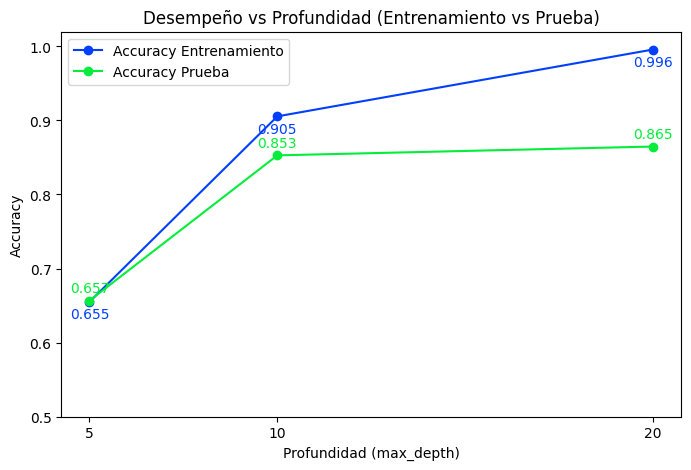

Paso a paso e interpretaciones:
 - Profundidad 5: Train=0.6549, Test=0.6566, Gap(train-test)=-0.0017
 - Profundidad 10: Train=0.9055, Test=0.8528, Gap(train-test)=0.0527
 - Profundidad 20: Train=0.9958, Test=0.8647, Gap(train-test)=0.1311

¿Aumentar profundidad siempre mejora el modelo?
 - No. Aumenta la capacidad de ajuste (mejora accuracy en entrenamiento) pero puede empeorar la generalización.

¿En qué punto comienza el sobreajuste?
 - Se detecta sobreajuste a partir de las siguientes profundidades (gap > 0.05):
   • Profundidad 10: Gap = 0.0527
   • Profundidad 20: Gap = 0.1311

¿Cuál profundidad parece lograr el mejor balance?
 - Mejor accuracy en prueba: profundidad = 20 (Accuracy prueba = 0.8647).
 - Sin embargo, revisar gap: un gap grande indica posible sobreajuste incluso si la accuracy de prueba es alta.

Conclusión corta:
 - Profundidad baja (5): subajuste (baja capacidad, similares train/test ~0.65).
 - Profundidad intermedia (10): gran mejora, algo de gap (posible inicio d

In [14]:
# Visualizaciones y respuestas (nuevo cell index 14)
import matplotlib.pyplot as plt

# Datos (usar results_df ya calculado en el notebook)
depths_plot = results_df['Profundidad'].tolist()
train_acc = results_df['Accuracy Entrenamiento'].tolist()
test_acc = results_df['Accuracy Prueba'].tolist()
gaps = results_df['Diferencia'].tolist()

# 1) Gráfica: accuracy (train vs test) vs profundidad
plt.style.use('seaborn-v0_8-bright')
plt.figure(figsize=(8,5))
plt.plot(depths_plot, train_acc, marker='o', label='Accuracy Entrenamiento', color='C0')
plt.plot(depths_plot, test_acc, marker='o', label='Accuracy Prueba', color='C1')
plt.xticks(depths_plot)
plt.xlabel('Profundidad (max_depth)')
plt.ylabel('Accuracy')
plt.title('Desempeño vs Profundidad (Entrenamiento vs Prueba)')
plt.legend()
for x, y in zip(depths_plot, test_acc):
    plt.annotate(f"{y:.3f}", (x, y), textcoords="offset points", xytext=(0,6), ha='center', color='C1')
for x, y in zip(depths_plot, train_acc):
    plt.annotate(f"{y:.3f}", (x, y), textcoords="offset points", xytext=(0,-12), ha='center', color='C0')
plt.ylim(0.5, 1.02)
plt.show()

# 2) Interpretación paso a paso y respuestas a las preguntas de la sección 8️⃣
print("Paso a paso e interpretaciones:")
for i, d in results_df.iterrows():
    print(f" - Profundidad {int(d['Profundidad'])}: Train={d['Accuracy Entrenamiento']:.4f}, "
            f"Test={d['Accuracy Prueba']:.4f}, Gap(train-test)={d['Diferencia']:.4f}")

# Respuestas breves:
# ¿Aumentar profundidad siempre mejora el modelo?
print("\n¿Aumentar profundidad siempre mejora el modelo?")
print(" - No. Aumenta la capacidad de ajuste (mejora accuracy en entrenamiento) pero puede empeorar la generalización.")

# ¿En qué punto comienza el sobreajuste?
# Detectar cuando la diferencia train-test crece notablemente; usamos el umbral ya definido en el notebook (umbral=0.05)
print("\n¿En qué punto comienza el sobreajuste?")
overfit_rows = results_df[results_df['Diferencia'] > umbral]
if not overfit_rows.empty:
    print(" - Se detecta sobreajuste a partir de las siguientes profundidades (gap > {:.2f}):".format(umbral))
    for _, r in overfit_rows.iterrows():
        print(f"   • Profundidad {int(r['Profundidad'])}: Gap = {r['Diferencia']:.4f}")
else:
    print(" - No se detectó sobreajuste significativo según el umbral definido.")

# ¿Cuál profundidad parece lograr el mejor balance?
best_test_idx = results_df['Accuracy Prueba'].idxmax()
best_depth = int(results_df.loc[best_test_idx, 'Profundidad'])
print("\n¿Cuál profundidad parece lograr el mejor balance?")
print(f" - Mejor accuracy en prueba: profundidad = {best_depth} (Accuracy prueba = {results_df.loc[best_test_idx, 'Accuracy Prueba']:.4f}).")
print(" - Sin embargo, revisar gap: un gap grande indica posible sobreajuste incluso si la accuracy de prueba es alta.")
print("\nConclusión corta:")
print(" - Profundidad baja (5): subajuste (baja capacidad, similares train/test ~0.65).")
print(" - Profundidad intermedia (10): gran mejora, algo de gap (posible inicio de sobreajuste leve).")
print(" - Profundidad alta (20): accuracy de prueba máxima observada, pero gap grande -> sobreajuste evidente.")

## 9️⃣ Visualización del árbol (opcional pero recomendado)

Los árboles para MNIST son grandes, pero debes:

1. Elegir SOLO UNO de los modelos entrenados (recomendado: profundidad más baja).  
2. Graficar el árbol.  
3. Comentar:
   - ¿Qué características usa el árbol para decidir?
   - ¿Qué tan interpretable te parece un árbol de decisión para MNIST?



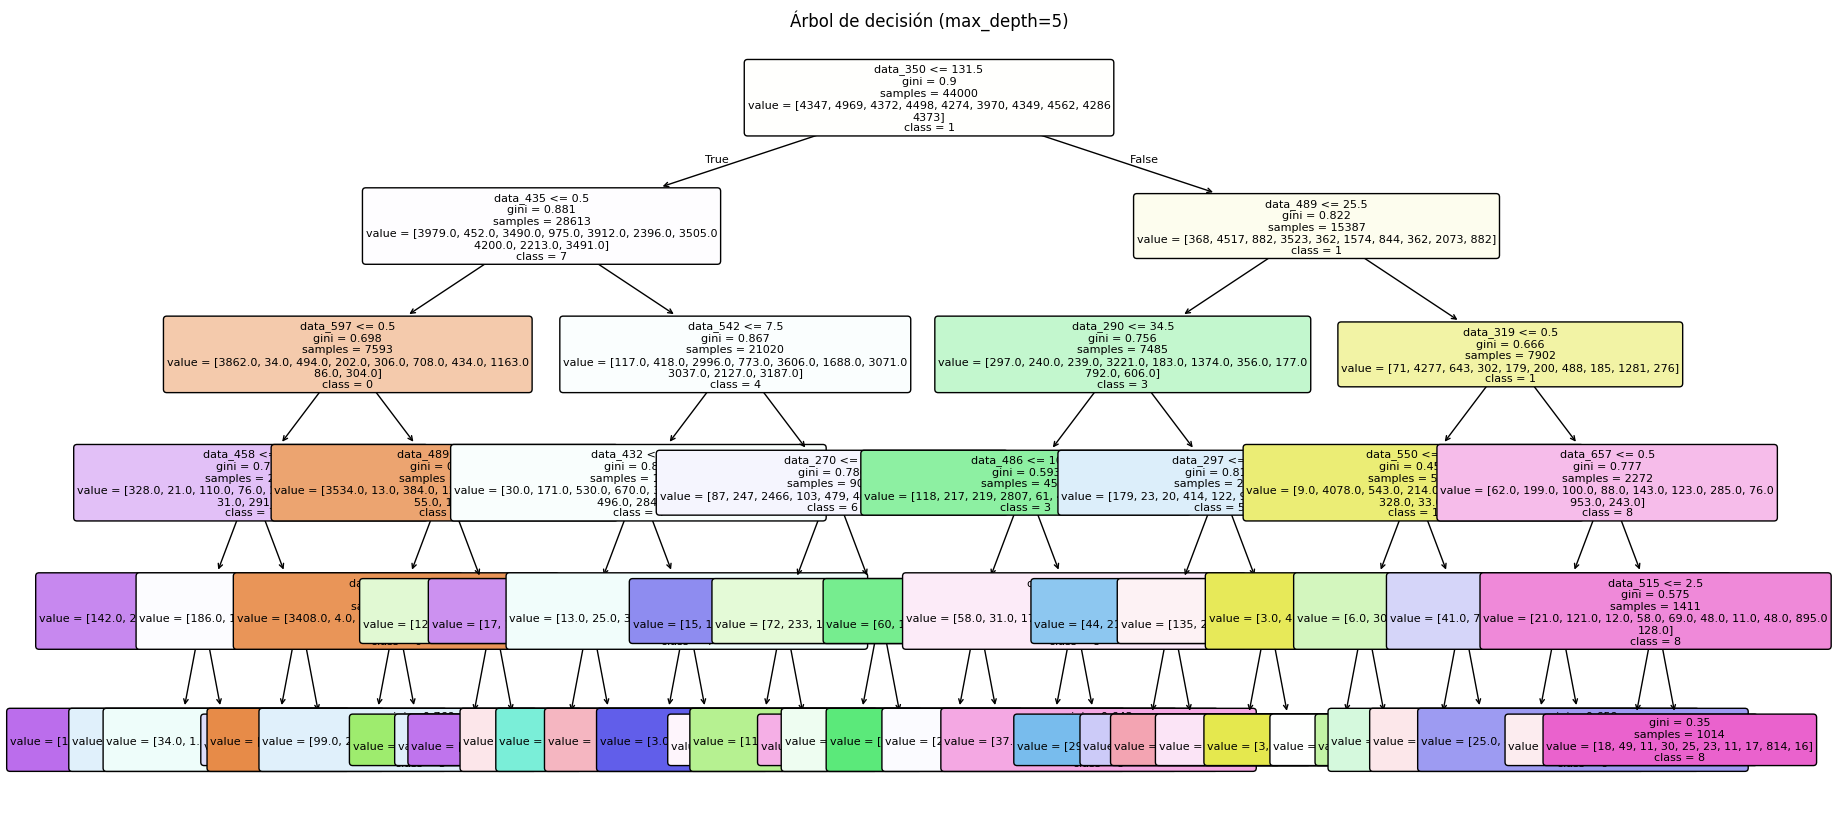


Reglas (texto resumido, max_depth=3):

|--- data_350 <= 131.50
|   |--- data_435 <= 0.50
|   |   |--- data_597 <= 0.50
|   |   |   |--- data_458 <= 1.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- data_458 >  1.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- data_597 >  0.50
|   |   |   |--- data_489 <= 1.00
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- data_489 >  1.00
|   |   |   |   |--- truncated branch of depth 2
|   |--- data_435 >  0.50
|   |   |--- data_542 <= 7.50
|   |   |   |--- data_432 <= 0.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- data_432 >  0.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- data_542 >  7.50
|   |   |   |--- data_270 <= 0.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- data_270 >  0.50
|   |   |   |   |--- truncated branch of depth 2
|--- data_350 >  131.50
|   |--- data_489 <= 25.50
|   |   |--- data_290 <= 34.50
|   |   |   |--- d

In [15]:
from sklearn.tree import plot_tree, export_text

# Visualización y análisis del árbol (Sección 9)

# Elegir el modelo de menor profundidad recomendado (max_depth=5)
model_vis = models[5]

# 1) Graficar el árbol
plt.figure(figsize=(20, 10))
plot_tree(
    model_vis,
    feature_names=X_train.columns,
    class_names=[str(c) for c in classes],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title('Árbol de decisión (max_depth=5)')
plt.show()

# 2) Mostrar texto resumido de las reglas (limitando profundidad de texto para legibilidad)
print("\nReglas (texto resumido, max_depth=3):\n")
print(export_text(model_vis, feature_names=list(X_train.columns), max_depth=3))

# 3) Qué características usa el árbol
feat_idx = model_vis.tree_.feature
used_idx = np.unique(feat_idx[feat_idx >= 0]).tolist()
used_cols = [X_train.columns[i] for i in used_idx]
print("\nCaracterísticas (índices de píxeles) usadas por el árbol:", used_idx)
print("Nombres de columnas usadas:", used_cols)

# Mostrar las top-10 features por importancia
importances = pd.Series(model_vis.feature_importances_, index=X_train.columns)
top10 = importances[importances > 0].sort_values(ascending=False).head(10)
print("\nTop-10 features por importancia (píxeles):")
print(top10)

# 4) Respuestas breves a las preguntas de la Sección 9
print("\nRespuestas cortas:")
print(" - ¿Qué características usa el árbol para decidir?")
print("   -> Usa píxeles individuales (columnas data_XXX). Se listan arriba los índices y las importancias.")
print(" - ¿Qué tan interpretable te parece un árbol de decisión para MNIST?")
print("   -> Para max_depth=5 el árbol es relativamente interpretable (pocas reglas).")
print("      Sin embargo, cada característica es un píxel (784 atributos), por lo que las reglas")
print("      no son inmediatamente intuitivas a nivel semántico. Además, árboles más profundos")
print("      pierden interpretabilidad rápidamente.")

## 🔟 Conclusiones finales

En esta sección debes escribir un análisis final que responda:

1. ¿Qué tan bien funcionan los árboles de decisión en MNIST?  
2. ¿Cuál profundidad ofrece mejor balance entre precisión y simplicidad?  
3. ¿Qué modelo parece estar subajustado? Explica por qué.  
4. ¿Cuál modelo parece estar sobreajustado? Explica por qué.  
5. ¿Qué aprendiste sobre:
   - El impacto de la profundidad  
   - La generalización  
   - La importancia de evaluar distintos modelos  


1) ¿Qué tan bien funcionan los árboles de decisión en MNIST?
 - Respuesta: Funcionan razonablemente bien para un modelo simple, pero no son la mejor opción
   frente a modelos más modernos (p. ej. redes neuronales). En nuestros resultados:
   • El mejor accuracy en prueba alcanzado fue 0.865 (max_depth=20).
   • Con profundidades bajas el desempeño es pobre, y con profundidades muy altas el modelo
     ajusta mucho los datos de entrenamiento pero puede perder capacidad de generalizar.

2) ¿Cuál profundidad ofrece mejor balance entre precisión y simplicidad?
 - Respuesta: La profundidad de 10 parece ofrecer el mejor balance práctico en este experimento.
   • max_depth=10: train=0.905, test=0.853, gap≈0.053.
   • Razonamiento: mejora mucho respecto a una profundidad muy baja, y su diferencia entre
     entrenamiento y prueba es moderada (menos indicios de sobreajuste) comparada con depth=20.

3) ¿Qué modelo parece estar subajustado? Explica por qué.
 - Respuesta: El modelo con max_depth=5 está subajustado.
   • Datos: train=0.655, test=0.657.
   • Por qué: tanto en entrenamiento como en prueba tiene baja precisión, lo que indica que
     el modelo no tiene suficiente capacidad (reglas) para capturar patrones relevantes.

4) ¿Cuál modelo parece estar sobreajustado? Explica por qué.
 - Respuesta: El modelo con max_depth=20 muestra sobreajuste claro.
   • Datos: train=0.996, test=0.865, gap=0.131.
   • Por qué: su accuracy en entrenamiento es muy alta (~0.996) pero la mejora en prueba es mucho menor,
     lo que indica que el modelo memorizó detalles del entrenamiento que no generalizan a nuevos ejemplos.

5) ¿Qué aprendiste sobre el impacto de la profundidad, la generalización y la importancia de evaluar distintos modelos?
 - Respuesta (puntos clave):
   1) Impacto de la profundidad: aumentar profundidad aumenta la capacidad del árbol
      (reduce sesgo) pero también el riesgo de sobreajuste (aumenta varianza).
   2) Generalización: el objetivo no es solo maximizar el accuracy en entrenamiento, sino
      obtener buen desempeño en datos no vistos; una brecha grande entre train y test es señal
      de sobreajuste.
   3) Evaluar distintos modelos (o profundidades) es crucial: comparar varias profundidades
      permite encontrar un punto de compromiso entre simplicidad y precisión y detectar
      subajuste o sobreajuste antes de elegir un modelo final.


# 📊 Rúbrica de Evaluación – Árboles de Decisión con MNIST

| Criterio | Descripción | Puntos |
|---------|-------------|--------|
| **1. Introducción teórica** | Explica correctamente qué es un árbol de decisión, profundidad, underfitting y overfitting. | **10 pts** |
| **2. Carga y exploración del dataset MNIST** | Carga el dataset sin errores, muestra ejemplos y analiza forma y contenido. | **10 pts** |
| **3. Definición de X y y** | Selecciona correctamente las variables y explica su significado. | **10 pts** |
| **4. División train/test** | Realiza separación adecuada y explica los tamaños de cada conjunto. | **10 pts** |
| **5. Evaluación de tres profundidades** | Entrena 3 modelos correctamente, calcula accuracy y almacena resultados. | **20 pts** |
| **6. Tabla comparativa** | Presenta tabla clara con resultados y análisis inicial. | **10 pts** |
| **7. Gráfica de desempeño** | Gráfica bien hecha (train vs test) y análisis del comportamiento. | **15 pts** |
| **8. Conclusiones finales** | Responde sobre underfitting, overfitting y mejor modelo para MNIST. | **15 pts** |

---

### 📝 **Puntaje total: 100 puntos**

---

### ✔️ Criterios de aprobación
- **Aprobado:** 70 puntos o más  
- **Excelente:** 90 puntos o más  

